<a href="https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/05_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#| default_exp datasets

In [ ]:
%%capture
!mkdir -p miniai
!wget -O miniai/training.py https://raw.githubusercontent.com/fastai/course22p2/master/miniai/training.py
!pip install datasets nbdev

In [ ]:
#|export
from __future__ import annotations
import math,numpy as np,matplotlib.pyplot as plt
from operator import itemgetter
from itertools import zip_longest
import fastcore.all as fc

from torch.utils.data import default_collate

from miniai.training import *

In [ ]:
import logging,pickle,gzip,os,time,shutil,torch,matplotlib as mpl
from pathlib import Path

from torch import tensor,nn,optim
from torch.utils.data import DataLoader
import torch.nn.functional as F
from datasets import load_dataset,load_dataset_builder

import torchvision.transforms.functional as TF
from fastcore.test import test_close

In [ ]:
torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
torch.manual_seed(1)
mpl.rcParams['image.cmap'] = 'gray'

In [ ]:
logging.disable(logging.WARNING)

## Hugging Face Datasets

- [Load a dataset from the Hub](https://huggingface.co/docs/datasets/load_hub)
- [Use with PyTorch](https://huggingface.co/docs/datasets/v2.4.0/use_with_pytorch)

In [ ]:
name = "fashion_mnist"
ds_builder = load_dataset_builder(name)
print(ds_builder.info.description)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.02k [00:00<?, ?B/s]

In [ ]:
ds_builder.info.features

{'image': Image(mode=None, decode=True, id=None),
 'label': ClassLabel(names=['T - shirt / top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'], id=None)}

A split is a specific subset of a dataset like train and test.

In [ ]:
ds_builder.info.splits

{'train': SplitInfo(name='train', num_bytes=31049107.0, num_examples=60000, shard_lengths=None, dataset_name=None),
 'test': SplitInfo(name='test', num_bytes=5192560.0, num_examples=10000, shard_lengths=None, dataset_name=None)}

so this is the difference between load
data set builder versus load data set so
this will actually download it cache it
and here it is and it creates a data set
dictionary
so a data set dictionary if you've used
Fast AI is basically just like what we
call the data sets plus they call the
data set dict class
so it's a dictionary that contains in
this case a train and a test item and
those are data sets these data sets are
very much like the data sets that we
created in the previous notebook

In [ ]:
dsd = load_dataset(name)
dsd

train-00000-of-00001.parquet:   0%|          | 0.00/30.9M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [ ]:
train,test = dsd['train'],dsd['test']
train[0] # dictionary 型式 (而非 pytorch 的 tuple 型式)

{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=28x28>,
 'label': 9}

(在 Python 中，當你這樣寫：
x, y = some_dict
其實是對 dict 進行「可迭代解包（iterable unpacking）」，而 dict 是 可迭代的（iterable），但 預設只會迭代它的 keys，等同於：
x, y = some_dict.keys())

In [ ]:
x,y = ds_builder.info.features

In [ ]:
x,y

('image', 'label')

In [ ]:
x,y = 'image','label'
img = train[0][x]
img

In [ ]:
xb = train[:5][x]
yb = train[:5][y]
yb

[9, 0, 0, 3, 0]

In [ ]:
train.features

{'image': Image(mode=None, decode=True, id=None),
 'label': ClassLabel(names=['T - shirt / top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'], id=None)}

In [ ]:
featy = train.features[y]
featy

ClassLabel(names=['T - shirt / top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'], id=None)

In [ ]:
featy.int2str(yb)

['Ankle boot',
 'T - shirt / top',
 'T - shirt / top',
 'Dress',
 'T - shirt / top']

In [ ]:
train['label'][:5]

[9, 0, 0, 3, 0]

In [ ]:
train

Dataset({
    features: ['image', 'label'],
    num_rows: 60000
})

```here it is so the thing to notice```

(可以把所有資料前處理的邏輯都塞進 collate_fn 裡處理，而不是寫一堆 Dataset 類別和 transform 函數。)

In [ ]:
def collate_fn(b):
    return {x:torch.stack([TF.to_tensor(o[x]) for o in b]),
            y:tensor([o[y] for o in b])}

| 維度位置 | 含義             | 值                           |
| ---- | -------------- | --------------------------- |
| `0`  | **Batch size** | `16`：代表一次取 16 張圖            |
| `1`  | **Channel 數**  | `1`：灰階圖像只有 1 個 channel      |
| `2`  | **影像高度 (H)**   | `28`：Fashion MNIST 高度 28 像素 |
| `3`  | **影像寬度 (W)**   | `28`：Fashion MNIST 寬度 28 像素 |

In [ ]:
dl = DataLoader(train, collate_fn=collate_fn, batch_size=16)
b = next(iter(dl))
b[x].shape,b[y]

(torch.Size([16, 1, 28, 28]),
 tensor([9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9]))

```so we can do```

(tds = train.with_transform(transforms) 這會產生一個新的 Dataset tds，它跟原本的 train dataset 差不多，但：
- 每次 \_\_getitem\_\_ 被呼叫時（一個 batch）（例如從 DataLoader 拿資料），就會先執行 transforms(b)。)

| 情境                                                   | `__getitem__()` 回傳什麼    |
| ---------------------------------------------------- | ----------------------- |
| 一般 map-style Dataset                                 | 單筆資料（dict or tuple）     |
| 搭配 `DataLoader(batch_size=N)` 且用了 `with_transform()` | 一個 batch（dict，包含 N 筆資料） |


so hacking face data sets has
something called with transform and
that's going to take your data set your
hugging face data set
and it's going to apply this function
to every element and it doesn't run at
all now it's going to basically when
when it behind the scenes when it calls
done to get item
it will call this function on the fly so
in other words this could have data
augmentation which can be random or
whatever because it's going to be rerun
every time you grab an item it's not
cached or anything like that

- [Custom format transform](https://huggingface.co/docs/datasets/v3.5.1/en/process#custom-format-transform)
- [api with_transform](https://huggingface.co/docs/datasets/v3.5.1/en/package_reference/main_classes#datasets.Dataset.with_transform)
  - Set \_\_getitem\_\_ return format using this transform. The transform is applied on-the-fly on batches when \_\_getitem\_\_ is called.

[classtorch.utils.data.Datase](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Dataset)
- Subclasses could also optionally implement \_\_getitems\_\_(), for speedup batched samples loading. This method accepts list of indices of samples of batch and returns list of samples.

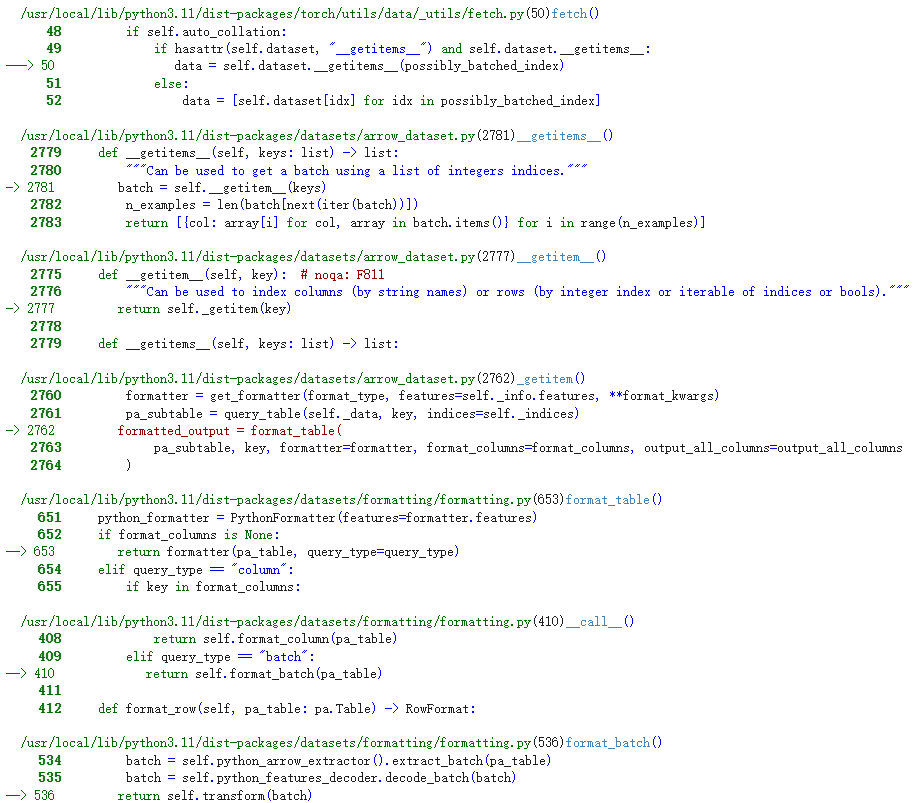

In [ ]:
def transforms(b):
    b[x] = [TF.to_tensor(o) for o in b[x]]
    return b

(PyTorch 的 DataLoader 預設就會把 dict of tensors 正確組成 batch，不需要再寫 collate_fn)

In [ ]:
tds = train.with_transform(transforms)
dl = DataLoader(tds, batch_size=16) # use default_collate()
b = next(iter(dl))
b[x].shape,b[y]

(torch.Size([16, 1, 28, 28]),
 tensor([9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9]))

In [ ]:
def _transformi(b): b[x] = [torch.flatten(TF.to_tensor(o)) for o in b[x]]

In [ ]:
#|export
def inplace(f):
    def _f(b): # wrapper
        f(b)
        return b
    return _f

In [ ]:
transformi = inplace(_transformi)

In [ ]:
r = train.with_transform(transformi)[0]
r[x].shape,r[y]

(torch.Size([784]), 9)

In [ ]:
@inplace
def transformi(b): b[x] = [torch.flatten(TF.to_tensor(o)) for o in b[x]]

In [ ]:
tdsf = train.with_transform(transformi)
r = tdsf[0]
r[x].shape,r[y]

(torch.Size([784]), 9)

In [ ]:
d = dict(a=1,b=2,c=3)
ig = itemgetter('a','c')
ig(d)

(1, 3)

In [ ]:
class D:
    def __getitem__(self, k): return 1 if k=='a' else 2 if k=='b' else 3

In [ ]:
d = D()
ig(d)

(1, 3)

In [ ]:
list(tdsf.features) # iterable unpacking

['image', 'label']

it also works on things that are tuples
not dictionaries which is what most of
you would have used before

In [ ]:
batch = dict(a=[1],b=[2]), dict(a=[3],b=[4])
default_collate(batch)

{'a': [tensor([1, 3])], 'b': [tensor([2, 4])]}

what this is going to do is
it's going to take a dictionary and
collate it into a tuple

In [ ]:
#|export
def collate_dict(ds):
    get = itemgetter(*ds.features)
    def _f(b): return get(default_collate(b))
    return _f

so this is um
a really important idea for particularly
for working with hugging face data sets
is that they tend to do things with
dictionaries and most other things in
the pytorch world tend to work with
tuples so you can just use this
now to convert anything that takes that
returns dictionaries into something that
provides tuples by passing it as a
collation function to your data loader

In [ ]:
dlf = DataLoader(tdsf, batch_size=4, collate_fn=collate_dict(tdsf))
xb,yb = next(iter(dlf))
xb.shape,yb

(torch.Size([4, 784]), tensor([9, 0, 0, 3]))

well in nbdev you
create a settings.ini file
where you say what the name of your
library is

## Plotting images

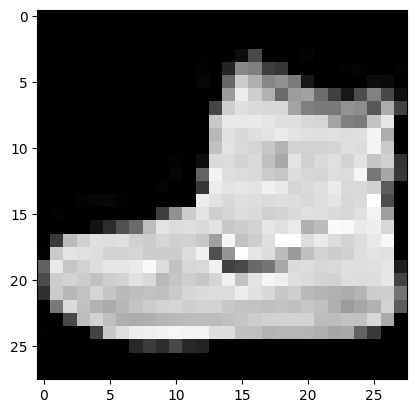

In [ ]:
b = next(iter(dl))
xb = b['image']
img = xb[0]
plt.imshow(img[0]);

| 功能              | `**kwargs` | `@fc.delegates()` |
| --------------- | ---------- | ----------------- |
| 接收額外參數          | ✅ 是        | ✅ 是               |
| 自動補文件與 IDE 支援   | ❌ 否        | ✅ 是               |
| 能幫助使用者知道有哪些參數可用 | ❌ 否        | ✅ 是               |
| 自動同步被委派對象的參數簽名  | ❌ 否        | ✅ 是               |

In [ ]:
#|export
@fc.delegates(plt.Axes.imshow)
def show_image(im, ax=None, figsize=None, title=None, noframe=True, **kwargs):
    "Show a PIL or PyTorch image on `ax`."
    if fc.hasattrs(im, ('cpu','permute','detach')): # 判斷是否為 PyTorch tensor
        im = im.detach().cpu()
        if len(im.shape)==3 and im.shape[0]<5: im=im.permute(1,2,0) # 如果影像是形狀 [C, H, W]（通道數小於5，一般是 RGB / 灰階），轉成 [H, W, C] 以便 matplotlib 顯示。
    elif not isinstance(im,np.ndarray): im=np.array(im) # 如果不是 NumPy array，也轉成 array（例如 PIL image）。
    if im.shape[-1]==1: im=im[...,0] # 若最後一維是 1（灰階），擠壓掉那一維 → [H, W, 1] → [H, W]
    if ax is None: _,ax = plt.subplots(figsize=figsize)
    ax.imshow(im, **kwargs)
    if title is not None: ax.set_title(title)
    ax.set_xticks([]) # 不顯示刻度
    ax.set_yticks([])
    if noframe: ax.axis('off') # 如果 noframe 為 True 就整個關掉框線。
    return ax

how come does it know how come it knows
what help to provide
the reason why is that fast core
has a special thing called delegates
which is a decorator so now you know
what a decorator is and you tell it what
is it that you're going to be passing
quarks to I'm going to be passing it to
I am show and then it automatically
creates the documentation
correctly to show you what quags can do

In [ ]:
help(show_image)

Help on function show_image in module __main__:

show_image(im, ax=None, figsize=None, title=None, noframe=True, *, cmap=None, norm=None, aspect=None, interpolation=None, alpha=None, vmin=None, vmax=None, colorizer=None, origin=None, extent=None, interpolation_stage=None, filternorm=True, filterrad=4.0, resample=None, url=None, data=None)
    Show a PIL or PyTorch image on `ax`.



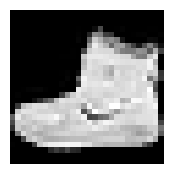

In [ ]:
show_image(img, figsize=(2,2));

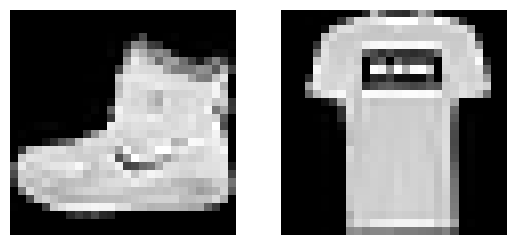

In [ ]:
fig,axs = plt.subplots(1,2)
show_image(img, axs[0])
show_image(xb[1], axs[1]);

In [ ]:
#|export
@fc.delegates(plt.subplots, keep=True)
def subplots(
    nrows:int=1, # Number of rows in returned axes grid
    ncols:int=1, # Number of columns in returned axes grid
    figsize:tuple=None, # Width, height in inches of the returned figure
    imsize:int=3, # Size (in inches) of images that will be displayed in the returned figure
    suptitle:str=None, # Title to be set to returned figure
    **kwargs
): # fig and axs
    "A figure and set of subplots to display images of `imsize` inches"
    if figsize is None: figsize=(ncols*imsize, nrows*imsize) # 如果 figsize 沒有指定，則根據子圖的行數（nrows）和列數（ncols）來計算圖形的大小。每個圖像的大小由 imsize 控制。
    fig,ax = plt.subplots(nrows, ncols, figsize=figsize, **kwargs)
    if suptitle is not None: fig.suptitle(suptitle)
    if nrows*ncols==1: ax = np.array([ax]) # 如果只有一個子圖（nrows * ncols == 1），ax 會是一個一維陣列，這樣便於在後續操作中以陣列形式統一處理，即 ax = np.array([ax])。
    return fig,ax

In [ ]:
from nbdev.showdoc import show_doc

In [ ]:
show_doc(subplots)

---

### subplots

>      subplots (nrows:int=1, ncols:int=1, figsize:tuple=None, imsize:int=3,
>                suptitle:str=None,
>                sharex:"bool|Literal['none','all','row','col']"=False,
>                sharey:"bool|Literal['none','all','row','col']"=False,
>                squeeze:bool=True, width_ratios:Sequence[float]|None=None,
>                height_ratios:Sequence[float]|None=None,
>                subplot_kw:dict[str,Any]|None=None,
>                gridspec_kw:dict[str,Any]|None=None, **kwargs)

*A figure and set of subplots to display images of `imsize` inches*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| nrows | int | 1 | Number of rows in returned axes grid |
| ncols | int | 1 | Number of columns in returned axes grid |
| figsize | tuple | None | Width, height in inches of the returned figure |
| imsize | int | 3 | Size (in inches) of images that will be displayed in the returned figure |
| suptitle | str | None | Title to be set to returned figure |
| sharex | bool \| Literal['none', 'all', 'row', 'col'] | False |  |
| sharey | bool \| Literal['none', 'all', 'row', 'col'] | False |  |
| squeeze | bool | True |  |
| width_ratios | Sequence[float] \| None | None |  |
| height_ratios | Sequence[float] \| None | None |  |
| subplot_kw | dict[str, Any] \| None | None |  |
| gridspec_kw | dict[str, Any] \| None | None |  |
| kwargs | VAR_KEYWORD |  |  |

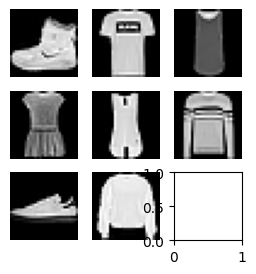

In [ ]:
fig,axs = subplots(3,3, imsize=1)
imgs = xb[:8]
for ax,img in zip(axs.flat,imgs): show_image(img, ax)

In [ ]:
#|export
@fc.delegates(subplots)
def get_grid(
    n:int, # Number of axes
    nrows:int=None, # Number of rows, defaulting to `int(math.sqrt(n))`
    ncols:int=None, # Number of columns, defaulting to `ceil(n/rows)`
    title:str=None, # If passed, title set to the figure
    weight:str='bold', # Title font weight
    size:int=14, # Title font size
    **kwargs,
): # fig and axs
    "Return a grid of `n` axes, `rows` by `cols`"
    # 自動計算行列數 (nrows, ncols):
    # 如果提供了 nrows，則會計算對應的 ncols，如果沒有提供 ncols，則會使用 n / nrows 向下取整的結果。
    # 如果提供了 ncols，則會計算對應的 nrows，如果沒有提供 nrows，則會使用 ceil(n / ncols) 向上取整的結果。
    # 如果都未提供，則會根據 n 自動計算，默認會根據平方根來決定行列數：
    #     nrows 設為 sqrt(n) 向下取整。
    #     ncols 設為 n / nrows 向下取整。
    if nrows: ncols = ncols or int(np.floor(n/nrows))
    elif ncols: nrows = nrows or int(np.ceil(n/ncols))
    else:
        nrows = int(math.sqrt(n))
        ncols = int(np.floor(n/nrows))
    fig,axs = subplots(nrows, ncols, **kwargs)
    for i in range(n, nrows*ncols): axs.flat[i].set_axis_off() # 在創建的圖形中，會有多餘的空白子圖（如果 n 不等於 nrows * ncols）。這些多餘的子圖會被關閉，也就是設定 set_axis_off()，使它們不顯示。
    if title is not None: fig.suptitle(title, weight=weight, size=size)
    return fig,axs

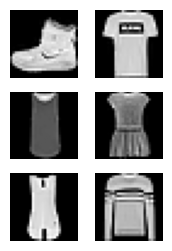

In [ ]:
fig,axs = get_grid(8, nrows=3, imsize=1)
for ax,img in zip(axs.flat,imgs): show_image(img, ax)

In [ ]:
#|export
@fc.delegates(subplots)
def show_images(ims:list, # Images to show
                nrows:int|None=None, # Number of rows in grid
                ncols:int|None=None, # Number of columns in grid (auto-calculated if None)
                titles:list|None=None, # Optional list of titles for each image
                **kwargs):
    "Show all images `ims` as subplots with `rows` using `titles`"
    axs = get_grid(len(ims), nrows, ncols, **kwargs)[1].flat # .flat 是將多維的 axs 陣列轉換為一維，這樣可以便於依次操作每個 ax（子圖的坐標）。
    # 使用 zip_longest 來迭代圖片 ims、標題 titles 和子圖 axs。這個函數會將三者打包成對，當某個列表長度不夠時，會自動補充 None（例如如果 titles 長度比 ims 少）。
    for im,t,ax in zip_longest(ims, titles or [], axs): show_image(im, ax=ax, title=t)

In [ ]:
yb = b['label']
lbls = yb[:8]

In [ ]:
names = "Top Trouser Pullover Dress Coat Sandal Shirt Sneaker Bag Boot".split()
titles = itemgetter(*lbls)(names) # itemgetter(*lbls) 會根據 lbls 中的值作為索引（假設 lbls 中的值是從 0 開始的數字）來選擇 names 中的元素，並生成一個新列表。
' '.join(titles)

'Boot Top Top Dress Top Pullover Sneaker Pullover'

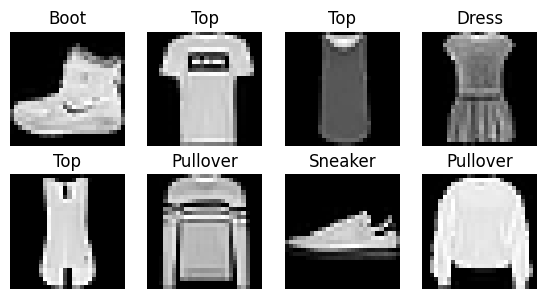

In [ ]:
show_images(imgs, imsize=1.7, titles=titles)

In [ ]:
#|export
class DataLoaders:
    def __init__(self, *dls): self.train,self.valid = dls[:2]

    @classmethod
    def from_dd(cls, dd, batch_size, as_tuple=True, **kwargs):
        f = collate_dict(dd['train'])
        return cls(*get_dls(*dd.values(), bs=batch_size, collate_fn=f, **kwargs))